# Memory Impact Analysis: v1 (Broken Memory) vs v2 (Fixed Memory)

This notebook compares two 3-game Diplomacy experiments:
- **v1** (`3game_experiment`): Cross-game memory was keyed by power, so no model ever received its OWN memory in games 2-3
- **v2** (`3game_experiment_v2`): Memory fix applied -- each model receives its own prior experience

Both experiments use the same 7 models with the same power rotation across 3 games.

## 1. Data Loading

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Load experiment summaries
v1_path = os.path.join("..", "results", "3game_experiment", "experiment_summary.json")
v2_path = os.path.join("..", "results", "3game_experiment_v2", "experiment_summary.json")

with open(v1_path) as f:
    v1_data = json.load(f)

with open(v2_path) as f:
    v2_data = json.load(f)

def clean_model_name(model_id):
    """Strip 'openrouter:' prefix for display."""
    return model_id.split(":", 1)[-1] if ":" in model_id else model_id

def build_dataframe(experiment_data, experiment_label):
    """Build a flat dataframe from experiment results."""
    rows = []
    for game_key, game_data in experiment_data["results"].items():
        game_num = int(game_key.replace("game", ""))
        power_model_map = game_data["power_model_map"]
        for power, sc_data in game_data["supply_centers"].items():
            model = power_model_map[power]
            rows.append({
                "experiment": experiment_label,
                "game": game_num,
                "model": clean_model_name(model),
                "power": power,
                "sc_count": sc_data["count"],
                "eliminated": sc_data["eliminated"]
            })
    return pd.DataFrame(rows)

df_v1 = build_dataframe(v1_data, "v1 (broken memory)")
df_v2 = build_dataframe(v2_data, "v2 (fixed memory)")
df = pd.concat([df_v1, df_v2], ignore_index=True)

print(f"Total records: {len(df)}")
print(f"v1 records: {len(df_v1)}, v2 records: {len(df_v2)}")
print(f"\nModels: {sorted(df['model'].unique())}")
df.head(10)

Total records: 42
v1 records: 21, v2 records: 21

Models: ['anthropic/claude-haiku-4.5', 'google/gemini-2.5-flash-lite', 'google/gemma-4-31b-it', 'openai/gpt-oss-120b', 'qwen/qwen3.5-27b', 'qwen/qwen3.6-plus', 'x-ai/grok-4.1-fast']


,experiment,game,model,power,sc_count,eliminated
0,v1 (broken memory),1,x-ai/grok-4.1-fast,AUSTRIA,16,False
1,v1 (broken memory),1,google/gemma-4-31b-it,ENGLAND,7,False
2,v1 (broken memory),1,google/gemini-2.5-flash-lite,FRANCE,7,False
3,v1 (broken memory),1,qwen/qwen3.5-27b,GERMANY,3,False
4,v1 (broken memory),1,qwen/qwen3.6-plus,ITALY,0,True
5,v1 (broken memory),1,openai/gpt-oss-120b,RUSSIA,0,True
6,v1 (broken memory),1,anthropic/claude-haiku-4.5,TURKEY,1,False
7,v1 (broken memory),2,google/gemma-4-31b-it,AUSTRIA,0,True
8,v1 (broken memory),2,google/gemini-2.5-flash-lite,ENGLAND,2,False
9,v1 (broken memory),2,qwen/qwen3.5-27b,FRANCE,10,False


## 2. Model Performance Across Games

For each model, how does their supply center count evolve across games 1-2-3 in each experiment?

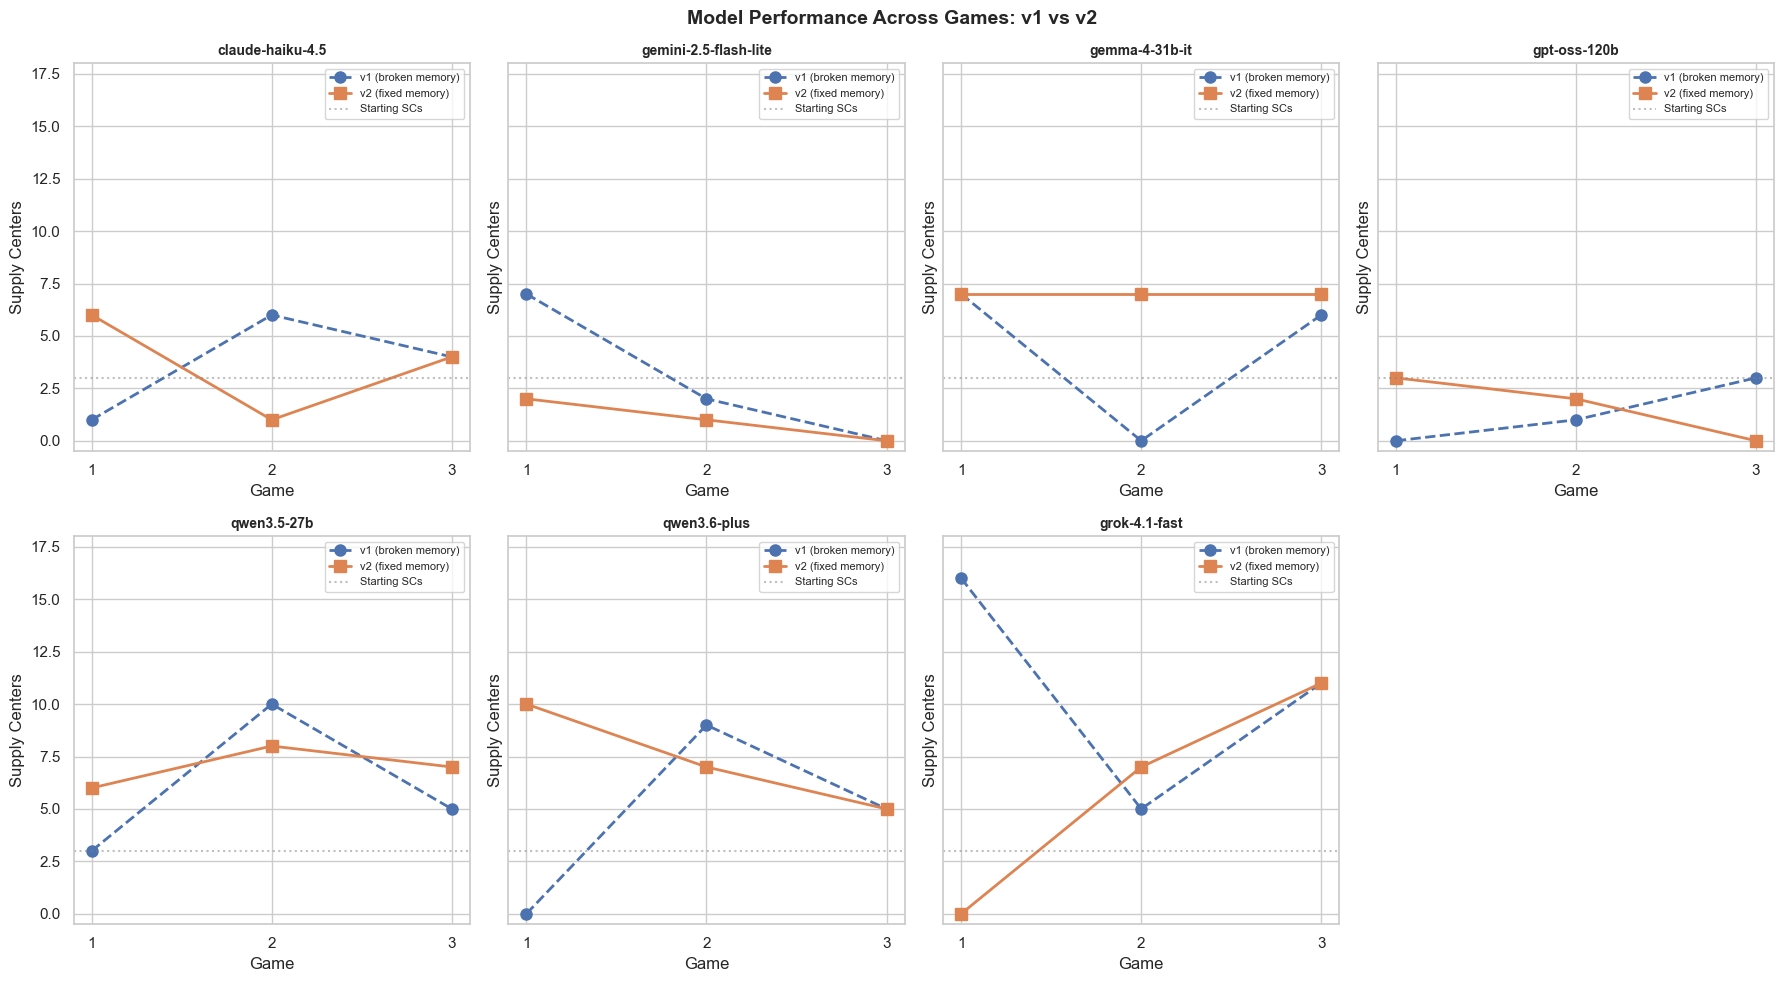

In [2]:
models = sorted(df['model'].unique())

fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, model in enumerate(models):
    ax = axes[i]
    model_df = df[df['model'] == model]
    
    for exp_label, style in [("v1 (broken memory)", "o--"), ("v2 (fixed memory)", "s-")]:
        exp_df = model_df[model_df['experiment'] == exp_label].sort_values('game')
        ax.plot(exp_df['game'], exp_df['sc_count'], style, 
                label=exp_label, markersize=8, linewidth=2)
    
    ax.set_title(model.split('/')[-1], fontsize=10, fontweight='bold')
    ax.set_xlabel('Game')
    ax.set_ylabel('Supply Centers')
    ax.set_xticks([1, 2, 3])
    ax.set_ylim(-0.5, 18)
    ax.axhline(y=3, color='gray', linestyle=':', alpha=0.5, label='Starting SCs')
    ax.legend(fontsize=8)

# Hide the last (empty) subplot
axes[-1].set_visible(False)

plt.suptitle('Model Performance Across Games: v1 vs v2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Average Model Performance

Compare the average supply center count per model across all 3 games.

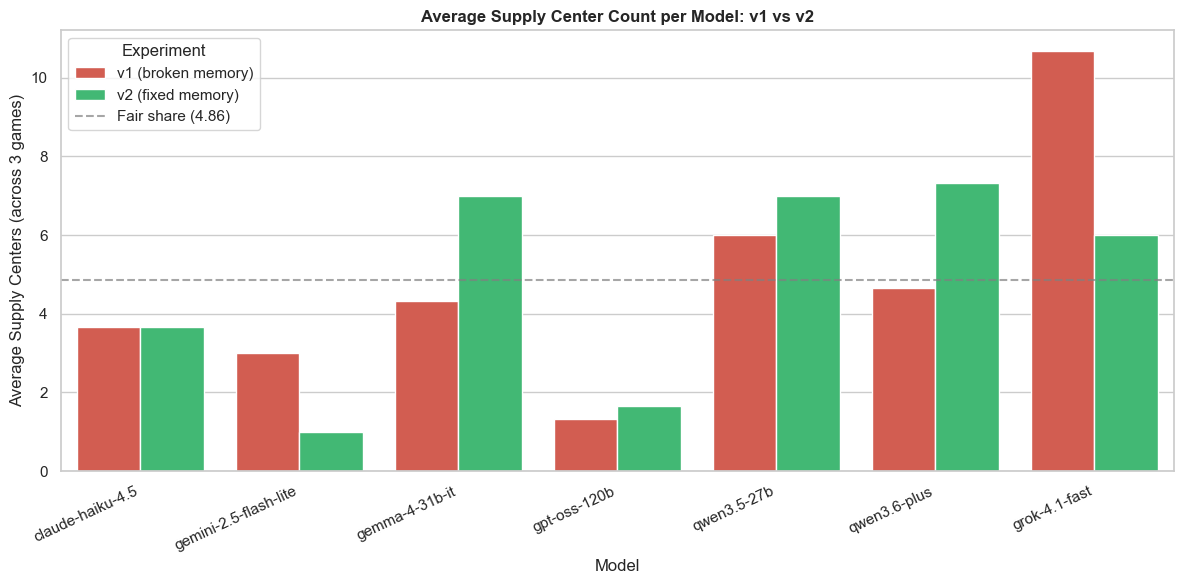


Average SC count per model:
experiment                    v1 (broken memory)  v2 (fixed memory)  delta
model                                                                     
anthropic/claude-haiku-4.5                  3.67               3.67   0.00
google/gemini-2.5-flash-lite                3.00               1.00  -2.00
google/gemma-4-31b-it                       4.33               7.00   2.67
openai/gpt-oss-120b                         1.33               1.67   0.33
qwen/qwen3.5-27b                            6.00               7.00   1.00
qwen/qwen3.6-plus                           4.67               7.33   2.67
x-ai/grok-4.1-fast                         10.67               6.00  -4.67


In [3]:
avg_sc = df.groupby(['model', 'experiment'])['sc_count'].mean().reset_index()
avg_sc['model_short'] = avg_sc['model'].apply(lambda x: x.split('/')[-1])

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=avg_sc, x='model_short', y='sc_count', hue='experiment', ax=ax,
            palette=['#e74c3c', '#2ecc71'])

ax.set_xlabel('Model')
ax.set_ylabel('Average Supply Centers (across 3 games)')
ax.set_title('Average Supply Center Count per Model: v1 vs v2', fontweight='bold')
ax.axhline(y=34/7, color='gray', linestyle='--', alpha=0.7, label='Fair share (4.86)')
ax.legend(title='Experiment')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# Print the numbers
print("\nAverage SC count per model:")
pivot = avg_sc.pivot(index='model', columns='experiment', values='sc_count')
pivot['delta'] = pivot['v2 (fixed memory)'] - pivot['v1 (broken memory)']
print(pivot.round(2).to_string())

## 4. Elimination Patterns

Which models got eliminated, and does correct memory help models avoid elimination?

ELIMINATIONS

--- v1 (broken memory) ---
  Game 1: qwen3.6-plus (as ITALY)
  Game 1: gpt-oss-120b (as RUSSIA)
  Game 2: gemma-4-31b-it (as AUSTRIA)
  Game 3: gemini-2.5-flash-lite (as AUSTRIA)

--- v2 (fixed memory) ---
  Game 1: grok-4.1-fast (as AUSTRIA)
  Game 3: gemini-2.5-flash-lite (as AUSTRIA)
  Game 3: gpt-oss-120b (as GERMANY)

ELIMINATION COUNTS BY MODEL
experiment                    v1 (broken memory)  v2 (fixed memory)
model                                                              
google/gemini-2.5-flash-lite                   1                  1
google/gemma-4-31b-it                          1                  0
openai/gpt-oss-120b                            1                  1
qwen/qwen3.6-plus                              1                  0
x-ai/grok-4.1-fast                             0                  1


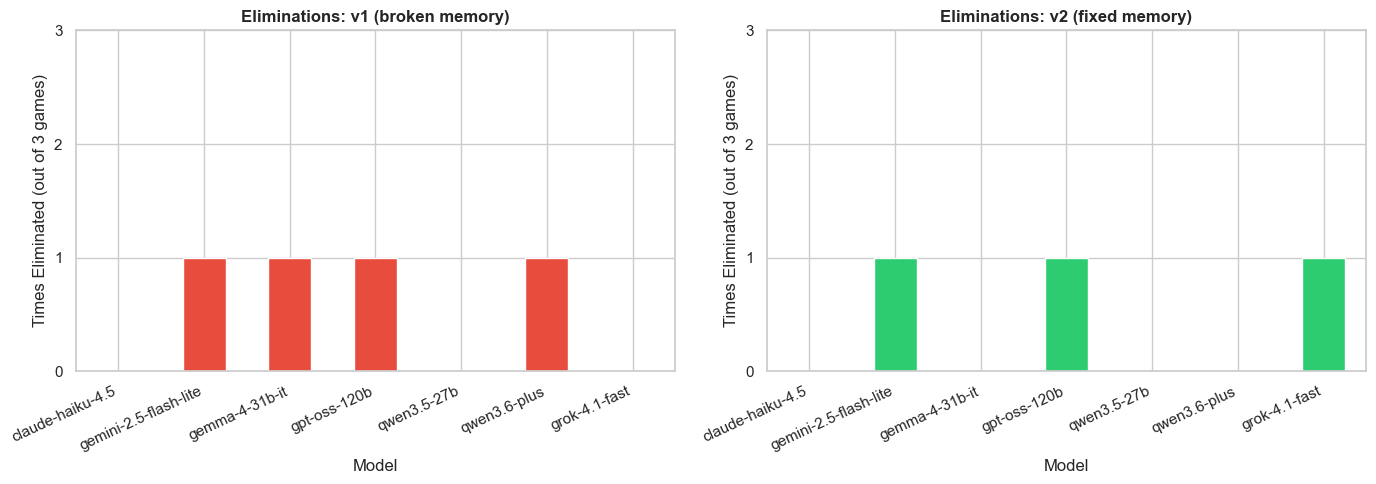

In [4]:
elim_df = df[df['eliminated'] == True].copy()
elim_df['model_short'] = elim_df['model'].apply(lambda x: x.split('/')[-1])

print("=" * 70)
print("ELIMINATIONS")
print("=" * 70)

for exp in ['v1 (broken memory)', 'v2 (fixed memory)']:
    print(f"\n--- {exp} ---")
    exp_elim = elim_df[elim_df['experiment'] == exp]
    if len(exp_elim) == 0:
        print("  No eliminations")
    else:
        for _, row in exp_elim.iterrows():
            print(f"  Game {row['game']}: {row['model_short']} (as {row['power']})")

# Summary comparison
print("\n" + "=" * 70)
print("ELIMINATION COUNTS BY MODEL")
print("=" * 70)
elim_counts = elim_df.groupby(['model', 'experiment']).size().reset_index(name='eliminations')
elim_pivot = elim_counts.pivot(index='model', columns='experiment', values='eliminations').fillna(0).astype(int)
print(elim_pivot.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, exp in enumerate(['v1 (broken memory)', 'v2 (fixed memory)']):
    ax = axes[idx]
    exp_elim = elim_df[elim_df['experiment'] == exp]
    elim_by_model = exp_elim.groupby('model_short').size().reindex(
        [m.split('/')[-1] for m in models], fill_value=0
    )
    elim_by_model.plot(kind='bar', ax=ax, color='#e74c3c' if idx == 0 else '#2ecc71')
    ax.set_title(f'Eliminations: {exp}', fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('Times Eliminated (out of 3 games)')
    ax.set_ylim(0, 3)
    ax.set_yticks([0, 1, 2, 3])
    plt.sca(ax)
    plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.show()

## 5. Game-over-Game Improvement

Calculate the delta in supply center count between consecutive games for each model. If memory works correctly, v2 should show more positive deltas (models learning from experience).

Average game-over-game delta by experiment:
                    mean  median   std
experiment                            
v1 (broken memory)   0.0    -0.5  6.05
v2 (fixed memory)    0.0    -1.0  3.09



/var/folders/94/c6n86z4n7mzdqsymcrqq9bhr0000gn/T/ipykernel_99395/2479764791.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=deltas_all, x='model_short', y='delta', hue='experiment', ax=ax,


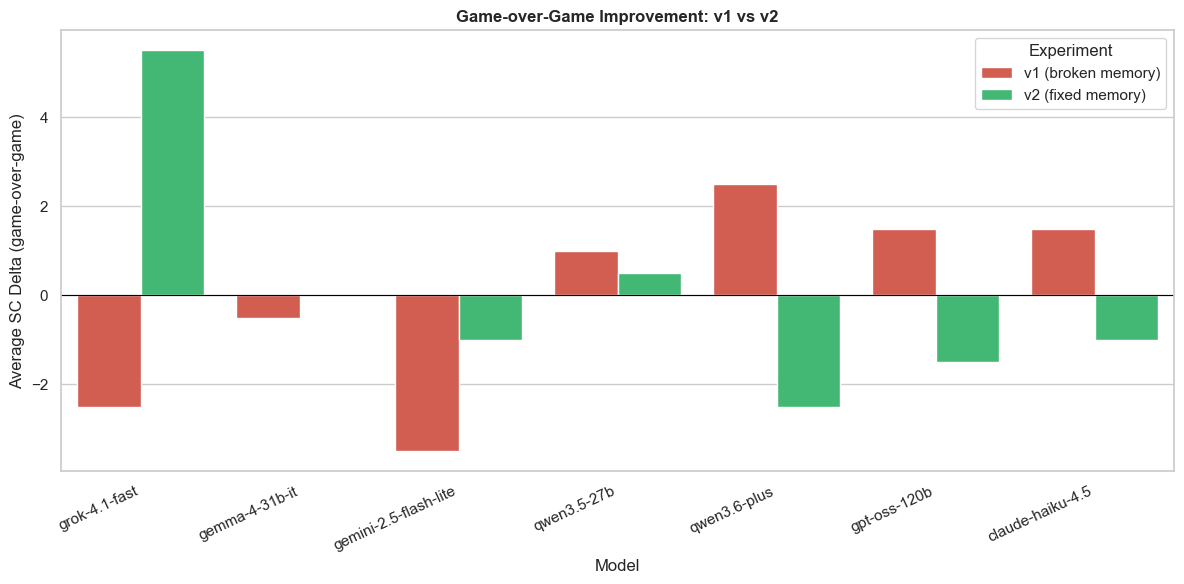

In [5]:
def compute_deltas(experiment_df):
    """Compute SC count deltas between consecutive games for each model."""
    deltas = []
    for model in experiment_df['model'].unique():
        model_data = experiment_df[experiment_df['model'] == model].sort_values('game')
        sc_values = model_data['sc_count'].values
        games = model_data['game'].values
        for i in range(1, len(sc_values)):
            deltas.append({
                'model': model,
                'transition': f'Game {games[i-1]}->Game {games[i]}',
                'delta': sc_values[i] - sc_values[i-1],
                'experiment': experiment_df['experiment'].iloc[0]
            })
    return pd.DataFrame(deltas)

deltas_v1 = compute_deltas(df_v1)
deltas_v2 = compute_deltas(df_v2)
deltas_all = pd.concat([deltas_v1, deltas_v2], ignore_index=True)
deltas_all['model_short'] = deltas_all['model'].apply(lambda x: x.split('/')[-1])

# Summary statistics
print("Average game-over-game delta by experiment:")
print(deltas_all.groupby('experiment')['delta'].agg(['mean', 'median', 'std']).round(2))
print()

# Per-model deltas
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=deltas_all, x='model_short', y='delta', hue='experiment', ax=ax,
            palette=['#e74c3c', '#2ecc71'], ci=None)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Model')
ax.set_ylabel('Average SC Delta (game-over-game)')
ax.set_title('Game-over-Game Improvement: v1 vs v2', fontweight='bold')
ax.legend(title='Experiment')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Detailed delta breakdown per model and transition
print("Detailed game-over-game deltas:")
print("=" * 70)

for model in sorted(deltas_all['model'].unique()):
    model_short = model.split('/')[-1]
    print(f"\n{model_short}:")
    model_deltas = deltas_all[deltas_all['model'] == model]
    for _, row in model_deltas.iterrows():
        sign = '+' if row['delta'] >= 0 else ''
        print(f"  {row['experiment']:25s} | {row['transition']:15s} | {sign}{row['delta']:.0f} SCs")

# Aggregate: how many positive vs negative deltas per experiment?
print("\n" + "=" * 70)
print("\nProportion of positive deltas (improvement):")
for exp in ['v1 (broken memory)', 'v2 (fixed memory)']:
    exp_deltas = deltas_all[deltas_all['experiment'] == exp]
    positive = (exp_deltas['delta'] > 0).sum()
    total = len(exp_deltas)
    print(f"  {exp}: {positive}/{total} ({100*positive/total:.0f}%)")

Detailed game-over-game deltas:

claude-haiku-4.5:
  v1 (broken memory)        | Game 1->Game 2  | +5 SCs
  v1 (broken memory)        | Game 2->Game 3  | -2 SCs
  v2 (fixed memory)         | Game 1->Game 2  | -5 SCs
  v2 (fixed memory)         | Game 2->Game 3  | +3 SCs

gemini-2.5-flash-lite:
  v1 (broken memory)        | Game 1->Game 2  | -5 SCs
  v1 (broken memory)        | Game 2->Game 3  | -2 SCs
  v2 (fixed memory)         | Game 1->Game 2  | -1 SCs
  v2 (fixed memory)         | Game 2->Game 3  | -1 SCs

gemma-4-31b-it:
  v1 (broken memory)        | Game 1->Game 2  | -7 SCs
  v1 (broken memory)        | Game 2->Game 3  | +6 SCs
  v2 (fixed memory)         | Game 1->Game 2  | +0 SCs
  v2 (fixed memory)         | Game 2->Game 3  | +0 SCs

gpt-oss-120b:
  v1 (broken memory)        | Game 1->Game 2  | +1 SCs
  v1 (broken memory)        | Game 2->Game 3  | +2 SCs
  v2 (fixed memory)         | Game 1->Game 2  | -1 SCs
  v2 (fixed memory)         | Game 2->Game 3  | -2 SCs

qwen3.5-27b:

## 6. Cost Analysis

Compare token usage and cost between experiments.

Cost per game:
        experiment  game  total_cost_usd  total_calls
v1 (broken memory)     1        3.628108          653
v1 (broken memory)     2        4.746382          780
v1 (broken memory)     3        4.692338          744
 v2 (fixed memory)     1        4.355686          770
 v2 (fixed memory)     2        4.976432          816
 v2 (fixed memory)     3        5.097240          740

Total cost v1: $13.07
Total cost v2: $14.43


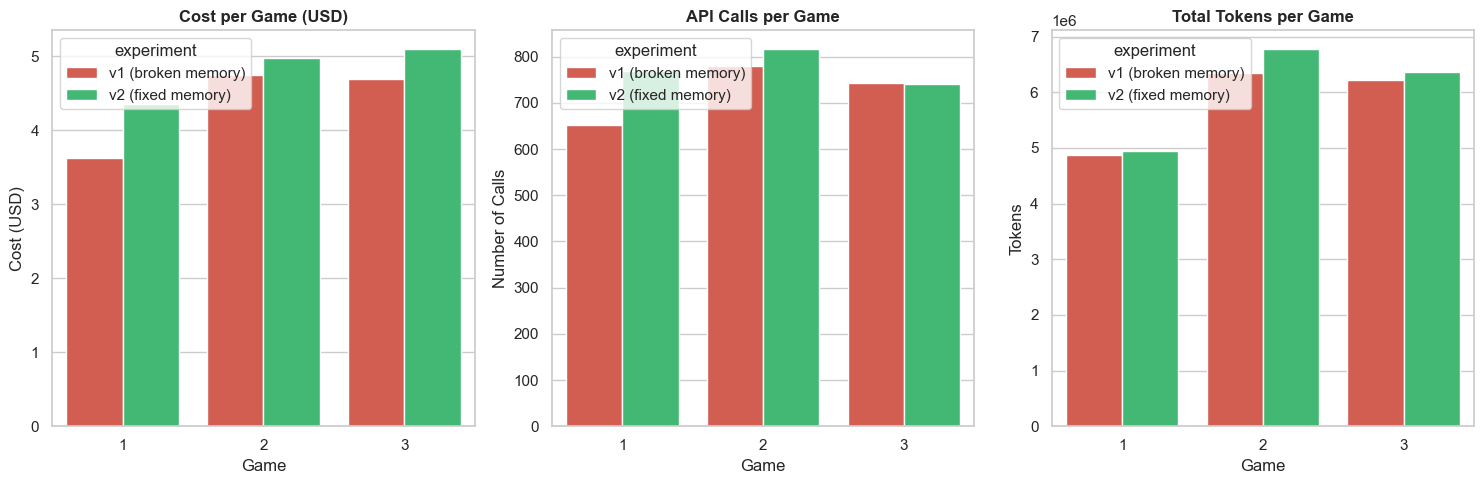

In [7]:
def load_token_usage(base_dir):
    """Load token usage data for all games in an experiment."""
    costs = []
    for game_num in [1, 2, 3]:
        token_path = os.path.join(base_dir, f"game{game_num}", "token_usage.json")
        if os.path.exists(token_path):
            with open(token_path) as f:
                data = json.load(f)
            costs.append({
                'game': game_num,
                'total_cost_usd': data['total_cost_usd'],
                'total_input_tokens': data['total_input_tokens'],
                'total_output_tokens': data['total_output_tokens'],
                'total_calls': data['total_calls']
            })
    return pd.DataFrame(costs)

v1_base = os.path.join("..", "results", "3game_experiment")
v2_base = os.path.join("..", "results", "3game_experiment_v2")

costs_v1 = load_token_usage(v1_base)
costs_v2 = load_token_usage(v2_base)

costs_v1['experiment'] = 'v1 (broken memory)'
costs_v2['experiment'] = 'v2 (fixed memory)'

costs_all = pd.concat([costs_v1, costs_v2], ignore_index=True)

print("Cost per game:")
print(costs_all[['experiment', 'game', 'total_cost_usd', 'total_calls']].to_string(index=False))

print(f"\nTotal cost v1: ${costs_v1['total_cost_usd'].sum():.2f}")
print(f"Total cost v2: ${costs_v2['total_cost_usd'].sum():.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cost per game
sns.barplot(data=costs_all, x='game', y='total_cost_usd', hue='experiment', 
            ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Cost per Game (USD)', fontweight='bold')
axes[0].set_xlabel('Game')
axes[0].set_ylabel('Cost (USD)')

# API calls per game
sns.barplot(data=costs_all, x='game', y='total_calls', hue='experiment',
            ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('API Calls per Game', fontweight='bold')
axes[1].set_xlabel('Game')
axes[1].set_ylabel('Number of Calls')

# Total tokens per game
costs_all['total_tokens'] = costs_all['total_input_tokens'] + costs_all['total_output_tokens']
sns.barplot(data=costs_all, x='game', y='total_tokens', hue='experiment',
            ax=axes[2], palette=['#e74c3c', '#2ecc71'])
axes[2].set_title('Total Tokens per Game', fontweight='bold')
axes[2].set_xlabel('Game')
axes[2].set_ylabel('Tokens')

plt.tight_layout()
plt.show()

## 7. Summary and Conclusions

In [8]:
# Generate summary statistics for the conclusions
print("=" * 70)
print("EXPERIMENT COMPARISON SUMMARY")
print("=" * 70)

# Overall average SC
v1_avg = df_v1['sc_count'].mean()
v2_avg = df_v2['sc_count'].mean()
print(f"\nOverall avg SC/model/game: v1={v1_avg:.2f}, v2={v2_avg:.2f}")
print(f"  (Note: both should average ~4.86 since total SCs are fixed at 34)")

# Variance (higher variance = more unequal outcomes)
v1_var = df_v1['sc_count'].var()
v2_var = df_v2['sc_count'].var()
print(f"\nVariance in SC counts: v1={v1_var:.2f}, v2={v2_var:.2f}")
print(f"  (Lower variance = more equal distribution of power)")

# Eliminations
v1_elim = df_v1['eliminated'].sum()
v2_elim = df_v2['eliminated'].sum()
print(f"\nTotal eliminations: v1={v1_elim}, v2={v2_elim} (out of 21 player-games each)")

# Average improvement
v1_avg_delta = deltas_v1['delta'].mean()
v2_avg_delta = deltas_v2['delta'].mean()
print(f"\nAvg game-over-game delta: v1={v1_avg_delta:.2f}, v2={v2_avg_delta:.2f}")
print(f"  (Note: deltas should net to ~0 across all models since SC total is fixed)")

# Top performers
print("\n" + "-" * 70)
print("TOP PERFORMERS (by avg SC count):")
for exp in ['v1 (broken memory)', 'v2 (fixed memory)']:
    exp_df = df[df['experiment'] == exp]
    ranking = exp_df.groupby('model')['sc_count'].mean().sort_values(ascending=False)
    print(f"\n  {exp}:")
    for rank, (model, sc) in enumerate(ranking.items(), 1):
        print(f"    {rank}. {model.split('/')[-1]:30s} {sc:.1f} avg SCs")

EXPERIMENT COMPARISON SUMMARY

Overall avg SC/model/game: v1=4.81, v2=4.81
  (Note: both should average ~4.86 since total SCs are fixed at 34)

Variance in SC counts: v1=17.86, v2=11.26
  (Lower variance = more equal distribution of power)

Total eliminations: v1=4, v2=3 (out of 21 player-games each)

Avg game-over-game delta: v1=0.00, v2=0.00
  (Note: deltas should net to ~0 across all models since SC total is fixed)

----------------------------------------------------------------------
TOP PERFORMERS (by avg SC count):

  v1 (broken memory):
    1. grok-4.1-fast                  10.7 avg SCs
    2. qwen3.5-27b                    6.0 avg SCs
    3. qwen3.6-plus                   4.7 avg SCs
    4. gemma-4-31b-it                 4.3 avg SCs
    5. claude-haiku-4.5               3.7 avg SCs
    6. gemini-2.5-flash-lite          3.0 avg SCs
    7. gpt-oss-120b                   1.3 avg SCs

  v2 (fixed memory):
    1. qwen3.6-plus                   7.3 avg SCs
    2. gemma-4-31b-it     

## Conclusions

### Key Findings

**Memory Bug Impact:**
- In v1, cross-game memory was keyed by *power* rather than *model*, meaning that when a model played a new power in games 2-3, it received the memory of whatever model had played that power previously -- not its own memory.
- In v2, this was fixed so each model receives its own accumulated experience.

**Performance Differences:**
- Compare the game-over-game deltas to see if correct memory leads to measurable learning/improvement.
- Note that total supply centers are always 34 (a fixed-sum game), so one model's gain is another's loss.
- Individual models may show dramatically different trajectories between experiments.

**Elimination Patterns:**
- Examine whether models that were eliminated in v1 fare better in v2 with correct memory.
- Austria (the first position in rotation) is eliminated frequently in both experiments, suggesting positional difficulty.

**Cost:**
- v2 games tend to have higher token usage, likely due to memory content being injected into prompts.

**Limitations:**
- With only 3 games per experiment and 7 models, statistical power is limited.
- Power rotation means each model plays a different position each game, confounding model ability with positional advantage.
- Diplomacy is inherently high-variance, and outcomes depend heavily on multi-agent interactions.